Converged at iteration 3 with PSNR: 31.09


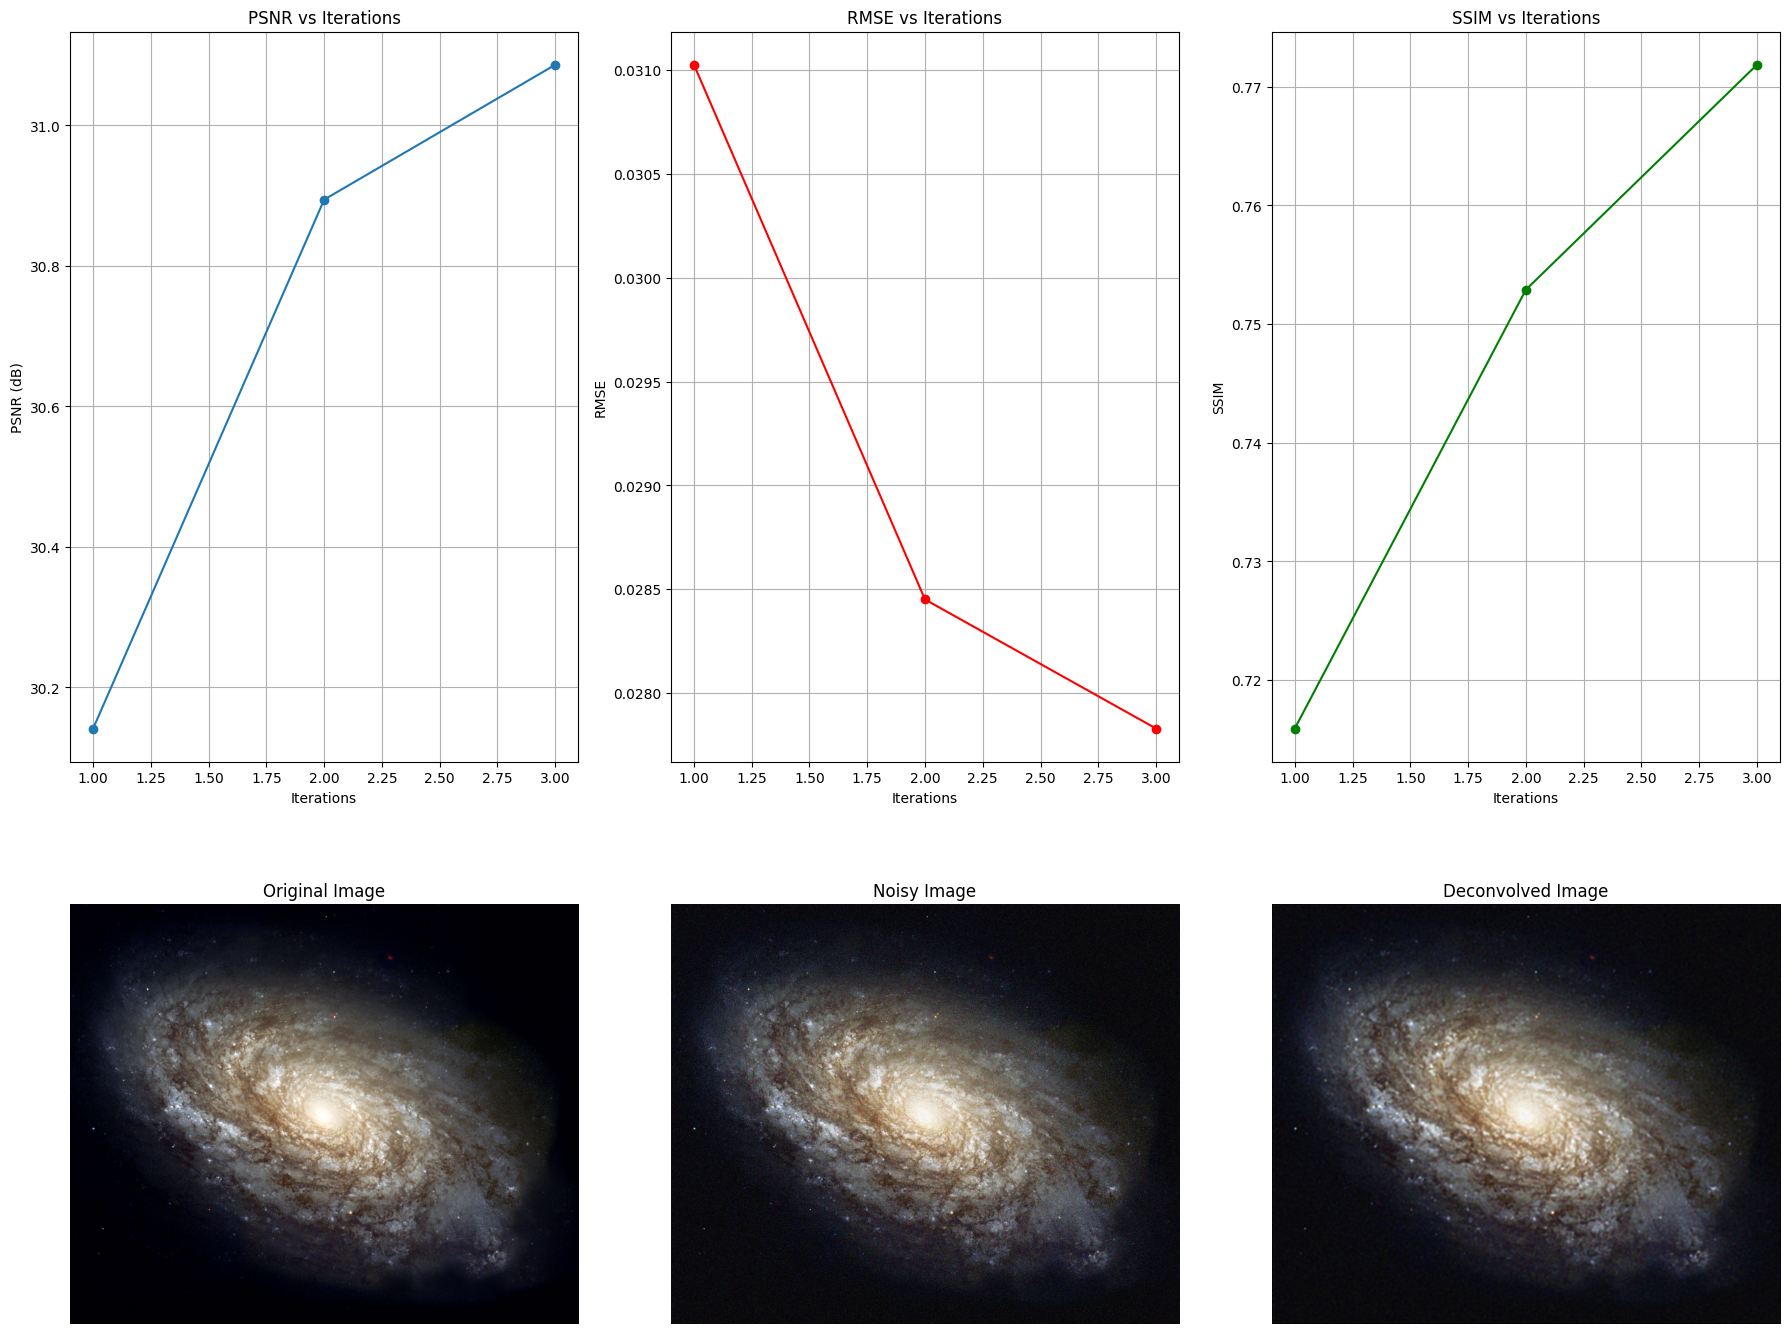

Final PSNR: 31.09
Final SSIM: 0.7718
Final RMSE: 0.0278


In [ ]:
import numpy as np
from scipy.signal import fftconvolve, wiener
from skimage import io, img_as_float
from skimage.restoration import denoise_bilateral
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import matplotlib.pyplot as plt


def add_noise(image, noise_type="gaussian", mean=0, var=0.01):
    """
    Add noise to an image.

    Parameters:
        image (ndarray): Original clear image.
        noise_type (str): Type of noise to add ('gaussian', 'salt_and_pepper').
        mean (float): Mean of Gaussian noise.
        var (float): Variance of Gaussian noise.

    Returns:
        noisy_image (ndarray): Image with added noise.
    """
    if noise_type == "gaussian":
        sigma = np.sqrt(var)
        noise = np.random.normal(mean, sigma, image.shape)
        noisy_image = image + noise
        noisy_image = np.clip(noisy_image, 0, 1)  # Clip to ensure pixel values are in [0, 1]
    elif noise_type == "salt_and_pepper":
        noisy_image = image.copy()
        prob = 0.02  # Probability of noise
        salt = np.random.rand(*image.shape) < prob / 2
        pepper = np.random.rand(*image.shape) < prob / 2
        noisy_image[salt] = 1
        noisy_image[pepper] = 0
    else:
        raise ValueError("Unsupported noise type. Choose 'gaussian' or 'salt_and_pepper'.")

    return noisy_image


def richardson_lucy(image, psf, max_iterations=50, tolerance=1e-5, init_reg_strength=0.2, min_reg_strength=0.05):
    """
    Richardson-Lucy deconvolution with adaptive regularization and edge-preserving smoothing.
    """
    image = image.astype(float)
    psf = psf.astype(float)
    psf /= psf.sum()
    im_deconv = np.full(image.shape, 0.5)
    psf_mirror = np.flip(psf)
    previous_psnr = 0

    # Set initial regularization strength
    reg_strength = init_reg_strength

    # Metrics tracking
    psnr_list = []
    ssim_list = []
    rmse_list = []

    for i in range(max_iterations):
        if image.ndim == 3:  # Color image
            conv = np.stack([fftconvolve(im_deconv[:, :, j], psf, mode='same') for j in range(3)], axis=-1)
            relative_blur = image / (conv + 1e-15)
            im_deconv *= np.stack([fftconvolve(relative_blur[:, :, j], psf_mirror, mode='same') for j in range(3)], axis=-1)
        else:  # Grayscale image
            conv = fftconvolve(im_deconv, psf, mode='same')
            relative_blur = image / (conv + 1e-15)
            im_deconv *= fftconvolve(relative_blur, psf_mirror, mode='same')

        # Adaptive regularization strength adjustment
        reg_strength = max(min_reg_strength, reg_strength * 0.95)

        # Apply edge-preserving smoothing (bilateral filter)
        if im_deconv.ndim == 3:  # Color image
            im_deconv = (1 - reg_strength) * im_deconv + reg_strength * np.stack(
                [denoise_bilateral(im_deconv[:, :, j], sigma_color=0.1, sigma_spatial=1) for j in range(3)],
                axis=-1
            )
        else:  # Grayscale image
            im_deconv = (1 - reg_strength) * im_deconv + reg_strength * denoise_bilateral(im_deconv, sigma_color=0.1, sigma_spatial=1)

        # Calculate metrics
        psnr = peak_signal_noise_ratio(image, im_deconv, data_range=image.max() - image.min())
        ssim = structural_similarity(image, im_deconv, data_range=image.max() - image.min(),
                                      channel_axis=-1 if image.ndim == 3 else None)
        rmse = np.sqrt(np.mean((image - im_deconv) ** 2))

        psnr_list.append(psnr)
        ssim_list.append(ssim)
        rmse_list.append(rmse)

        if np.abs(psnr - previous_psnr) < tolerance:
            print(f"Converged at iteration {i+1} with PSNR: {psnr:.2f}")
            break
        previous_psnr = psnr

    return im_deconv, psnr_list, ssim_list, rmse_list


def generate_psf(shape, sigma_x=3, sigma_y=3):
    """
    Generate an anisotropic Gaussian PSF with separate sigma values for x and y.
    """
    x, y = np.mgrid[-shape//2 + 1:shape//2 + 1, -shape//2 + 1:shape//2 + 1]
    g = np.exp(-((x**2 / (2.0 * sigma_x ** 2)) + (y**2 / (2.0 * sigma_y ** 2))))
    return g / g.sum()
def process_image(image_path, psf_size=15, sigma_x=3, sigma_y=3, max_iterations=50, init_reg_strength=0.2, min_reg_strength=0.05):
    # Load and preprocess image
    original = img_as_float(io.imread(image_path))

    # Add noise to the image
    noisy_image = add_noise(original, noise_type="gaussian", mean=0, var=0.01)

    # Apply Wiener filter to reduce initial noise
    wiener_filtered = np.zeros_like(noisy_image)
    if noisy_image.ndim == 3:  # Color image
        for i in range(noisy_image.shape[2]):  # Process each channel
            wiener_filtered[:, :, i] = wiener(noisy_image[:, :, i], [5, 5])
    else:  # Grayscale image
        wiener_filtered = wiener(noisy_image, [5, 5])

    # Generate PSF with custom anisotropic sigma
    psf = generate_psf(psf_size, sigma_x, sigma_y)

    # Apply Richardson-Lucy deconvolution
    deconvolved, psnr_list, ssim_list, rmse_list = richardson_lucy(wiener_filtered, psf, max_iterations, init_reg_strength, min_reg_strength)

    # Plot metrics and images
    iterations = np.arange(1, len(psnr_list) + 1)

    # Create figure
    fig, axes = plt.subplots(2, 3, figsize=(18, 15))

    # PSNR vs Iterations
    axes[0, 0].plot(iterations, psnr_list, label="PSNR", marker='o')
    axes[0, 0].set_title("PSNR vs Iterations")
    axes[0, 0].set_xlabel("Iterations")
    axes[0, 0].set_ylabel("PSNR (dB)")
    axes[0, 0].grid(True)

    # RMSE vs Iterations
    axes[0, 1].plot(iterations, rmse_list, label="RMSE", marker='o', color='r')
    axes[0, 1].set_title("RMSE vs Iterations")
    axes[0, 1].set_xlabel("Iterations")
    axes[0, 1].set_ylabel("RMSE")
    axes[0, 1].grid(True)

    # SSIM vs Iterations
    axes[0, 2].plot(iterations, ssim_list, label="SSIM", marker='o', color='g')
    axes[0, 2].set_title("SSIM vs Iterations")
    axes[0, 2].set_xlabel("Iterations")
    axes[0, 2].set_ylabel("SSIM")
    axes[0, 2].grid(True)

    # Original Image
    axes[1, 0].imshow(original, cmap='gray' if original.ndim == 2 else None)
    axes[1, 0].set_title("Original Image")
    axes[1, 0].axis('off')

    # Noisy Image
    axes[1, 1].imshow(noisy_image, cmap='gray' if noisy_image.ndim == 2 else None)
    axes[1, 1].set_title("Noisy Image")
    axes[1, 1].axis('off')

    # Deconvolved Image
    axes[1, 2].imshow(deconvolved, cmap='gray' if deconvolved.ndim == 2 else None)
    axes[1, 2].set_title("Deconvolved Image")
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

    return deconvolved, psnr_list[-1], ssim_list[-1], rmse_list[-1]  # Ensure RMSE is returned


# Usage
image_path = '/content/drive/MyDrive/image_spm/image_reconstruction2/9.jpg'
deconvolved, final_psnr, final_ssim, final_rmse = process_image(image_path, psf_size=15, sigma_x=3, sigma_y=3, max_iterations=50, init_reg_strength=0.2, min_reg_strength=0.05)

# Print the final metrics
print(f'Final PSNR: {final_psnr:.2f}')
print(f'Final SSIM: {final_ssim:.4f}')
print(f'Final RMSE: {final_rmse:.4f}')
